C:\WINDOWS\system32\myenv\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 0.2774 - mae: 0.4768 - val_loss: 0.3046 - val_mae: 0.4734
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1915 - mae: 0.3771 - val_loss: 0.2095 - val_mae: 0.3818
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1174 - mae: 0.2877 - val_loss: 0.1008 - val_mae: 0.2677
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0658 - mae: 0.2063 - val_loss: 0.0640 - val_mae: 0.2213
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0571 - mae: 0.1917 - val_loss: 0.0651 - val_mae: 0.2268
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0494 - mae: 0.1776 - val_loss: 0.0711 - val_mae: 0.2364
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0398 - mae: 0.1590 - val_loss: 0.0652 - val_mae: 0.2283
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0374 - mae: 0.1557 - val_loss: 0.0613 - val_mae: 0.2221
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - lo

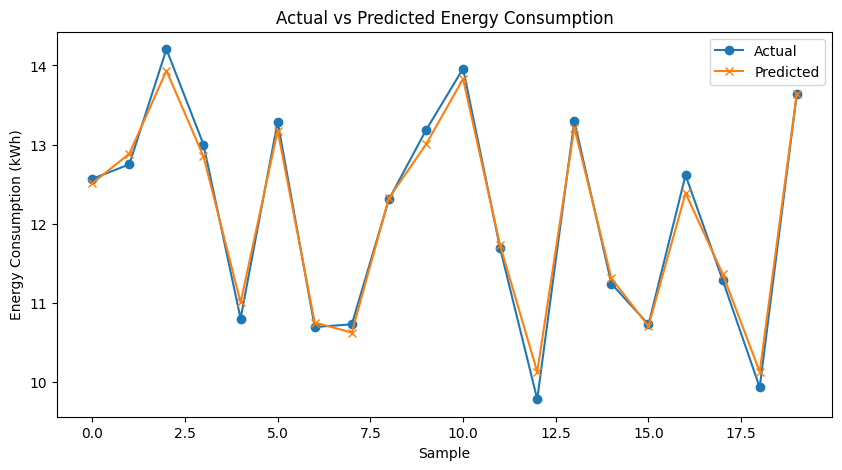

In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
file_path = "C:/Users/Anarghya/OneDrive/Desktop/major project/energy_consumption_dataset in csv.csv" 
df = pd.read_csv(file_path)

# Encode categorical variable (Weather)
df["Weather"] = LabelEncoder().fit_transform(df["Weather"])

# Select features and target
X = df.drop(columns=["Total Energy Consumption (kWh)"])
y = df["Total Energy Consumption (kWh)"]

# Normalize data
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Reshape for LSTM (samples, time steps, features)
X_lstm = np.reshape(X_scaled, (X_scaled.shape[0], 1, X_scaled.shape[1]))

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_lstm, y_scaled, test_size=0.2, random_state=42, shuffle=True)

# Define LSTM model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(1, X_train.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

# Compile model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Train model with early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100, batch_size=8, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)

# Predictions
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_inv = scaler_y.inverse_transform(y_test)

# Display Prediction
print(y_pred)

# Evaluation Metrics
mse = mean_squared_error(y_test_inv, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_inv, y_pred)

print(f"\nMSE: {mse:.4f}\nRMSE: {rmse:.4f}\nR²: {r2:.4f}")

# Plot Predictions vs Actual
plt.figure(figsize=(10, 5))
plt.plot(y_test_inv, label="Actual", marker='o')
plt.plot(y_pred, label="Predicted", marker='x')
plt.xlabel("Sample")
plt.ylabel("Energy Consumption (kWh)")
plt.legend()
plt.title("Actual vs Predicted Energy Consumption")
plt.show()

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Define energy consumption categories
def categorize_energy(value, low_thresh, high_thresh):
    if value < low_thresh:
        return "Low"
    elif value < high_thresh:
        return "Medium"
    else:
        return "High"

# Define thresholds based on percentiles
low_threshold = np.percentile(y_test_inv, 33)
high_threshold = np.percentile(y_test_inv, 66)

# Convert actual and predicted values to categories
y_test_class = np.array([categorize_energy(val, low_threshold, high_threshold) for val in y_test_inv.flatten()])
y_pred_class = np.array([categorize_energy(val, low_threshold, high_threshold) for val in y_pred.flatten()])

# Create confusion matrix
conf_matrix = confusion_matrix(y_test_class, y_pred_class, labels=["Low", "Medium", "High"])

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Energy Consumption Categories")
plt.show()

# Print classification report
print(classification_report(y_test_class, y_pred_class))


ModuleNotFoundError: No module named 'seaborn'

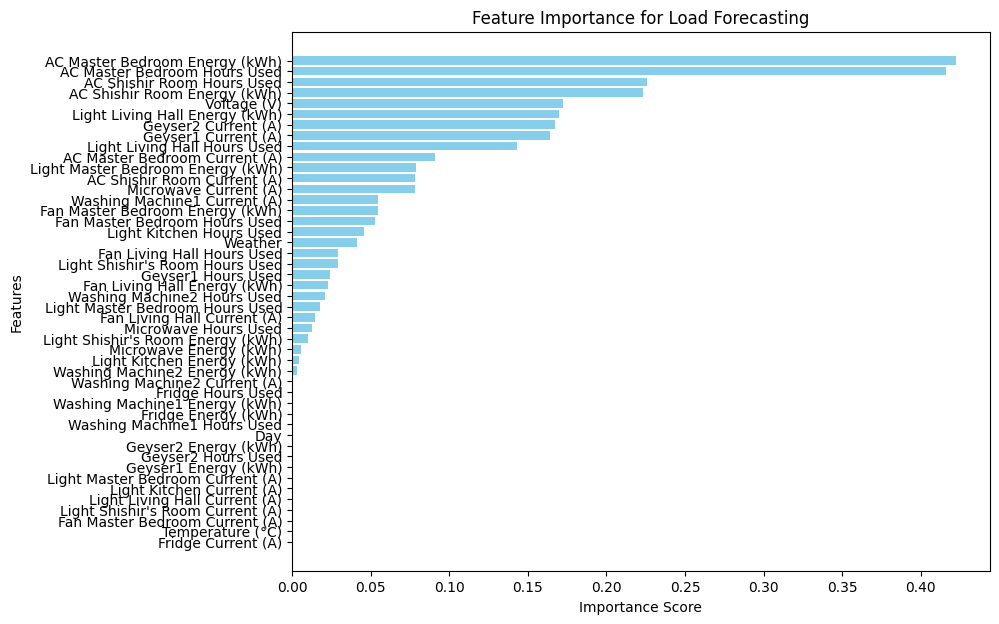

                              Feature  Importance
8      AC Master Bedroom Energy (kWh)    0.422772
7        AC Master Bedroom Hours Used    0.416392
4          AC Shishir Room Hours Used    0.225544
5        AC Shishir Room Energy (kWh)    0.223232
3                         Voltage (V)    0.172629
20     Light Living Hall Energy (kWh)    0.169858
36                Geyser2 Current (A)    0.167412
33                Geyser1 Current (A)    0.164274
19       Light Living Hall Hours Used    0.142794
9       AC Master Bedroom Current (A)    0.090783
26  Light Master Bedroom Energy (kWh)    0.078976
6         AC Shishir Room Current (A)    0.078365
30              Microwave Current (A)    0.077879
39       Washing Machine1 Current (A)    0.054824
14    Fan Master Bedroom Energy (kWh)    0.054606
13      Fan Master Bedroom Hours Used    0.052766
22           Light Kitchen Hours Used    0.045841
1                             Weather    0.041198
10         Fan Living Hall Hours Used    0.029417


In [3]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_regression
import matplotlib.pyplot as plt

# Load dataset
file_path = "C:/Users/Anarghya/OneDrive/Desktop/major project/energy_consumption_dataset in csv.csv"
df = pd.read_csv(file_path)

# Encode categorical variable (if any)
df["Weather"] = df["Weather"].astype("category").cat.codes  # Convert categorical to numeric

# Select features and target
X = df.drop(columns=["Total Energy Consumption (kWh)"])  # Features
y = df["Total Energy Consumption (kWh)"]  # Target variable

# Compute feature importance using Mutual Information
feature_importance = mutual_info_regression(X, y)

# Create a DataFrame to store and sort feature importance
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# Plot feature importance
plt.figure(figsize=(9, 7))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"], color='skyblue')
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance for Load Forecasting")
plt.gca().invert_yaxis()
plt.show()

# Display ranked features
print(feature_importance_df)

Epoch 1/100


C:\WINDOWS\system32\myenv\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.2171 - mae: 0.4176 - val_loss: 0.2304 - val_mae: 0.4054
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1502 - mae: 0.3319 - val_loss: 0.1032 - val_mae: 0.2687
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0615 - mae: 0.1947 - val_loss: 0.0588 - val_mae: 0.2103
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0488 - mae: 0.1812 - val_loss: 0.0586 - val_mae: 0.2114
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0515 - mae: 0.1781 - val_loss: 0.0696 - val_mae: 0.2336
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0408 - mae: 0.1671 - val_loss: 0.0623 - val_mae: 0.2226
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0476 - mae: 0.1688 - val_loss: 0.0550 - val_mae: 0.2078
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0429 - mae: 0.1673 - val_loss: 0.0542 - val_mae: 0.2071
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0371 -

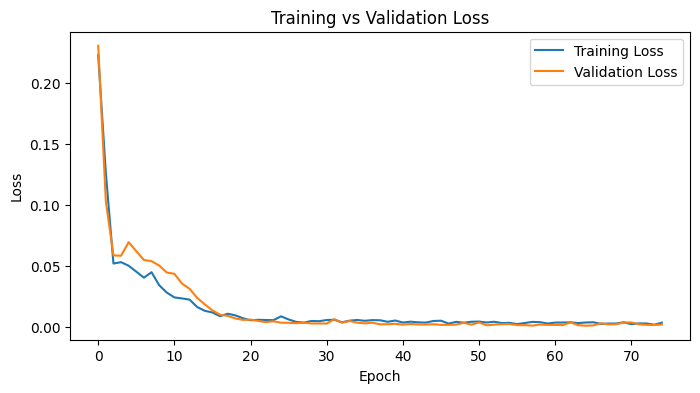

In [4]:

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error


# Load dataset
file_path = "C:/Users/Anarghya/OneDrive/Desktop/major project/energy_consumption_dataset in csv.csv" 
df = pd.read_csv(file_path)

# Encode categorical variable (Weather)
df["Weather"] = LabelEncoder().fit_transform(df["Weather"])

# Select features and target
X = df.drop(columns=["Total Energy Consumption (kWh)"])
y = df["Total Energy Consumption (kWh)"]

# Normalize data
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Reshape for LSTM (samples, time steps, features)
X_lstm = np.reshape(X_scaled, (X_scaled.shape[0], 1, X_scaled.shape[1]))

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_lstm, y_scaled, test_size=0.2, random_state=42, shuffle=True)

# Define LSTM model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(1, X_train.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

# Compile model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Train model with early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100, batch_size=8, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)

# Predictions
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_inv = scaler_y.inverse_transform(y_test)

# Display Prediction
print(y_pred)

# Evaluation Metrics
mse = mean_squared_error(y_test_inv, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_inv, y_pred)
mae = mean_absolute_error(y_test_inv, y_pred)


print(f"\nMSE: {mse:.4f}\nRMSE: {rmse:.4f}\nR²: {r2:.4f}\nMAE: {mae:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

Epoch 1/100


C:\WINDOWS\system32\myenv\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.2510 - mae: 0.4447 - val_loss: 0.2213 - val_mae: 0.3989
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1188 - mae: 0.2892 - val_loss: 0.0960 - val_mae: 0.2560
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0544 - mae: 0.1985 - val_loss: 0.0598 - val_mae: 0.2025
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0667 - mae: 0.2100 - val_loss: 0.0609 - val_mae: 0.2137
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0401 - mae: 0.1711 - val_loss: 0.0700 - val_mae: 0.2311
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0638 - mae: 0.2014 - val_loss: 0.0602 - val_mae: 0.2153
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0352 - mae: 0.1455 - val_loss: 0.0576 - val_mae: 0.2116
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0357 - mae: 0.1522 - val_loss: 0.0566 - val_mae: 0.2111
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0426 -

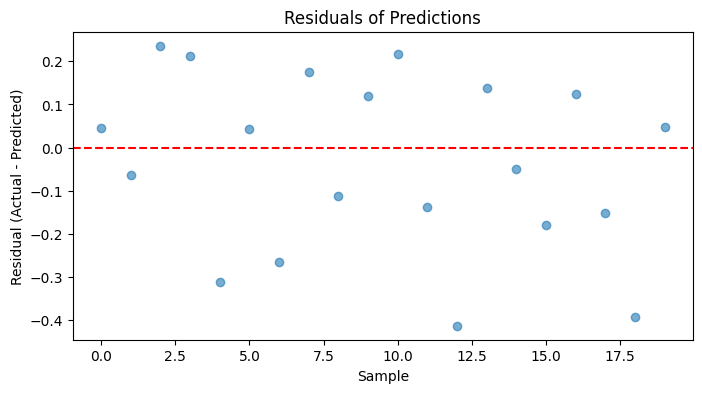

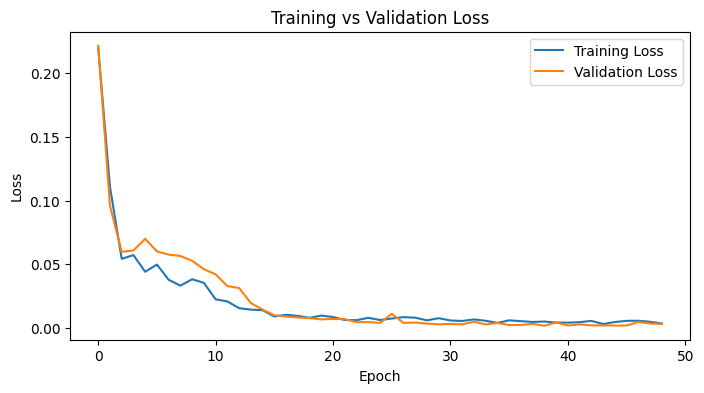

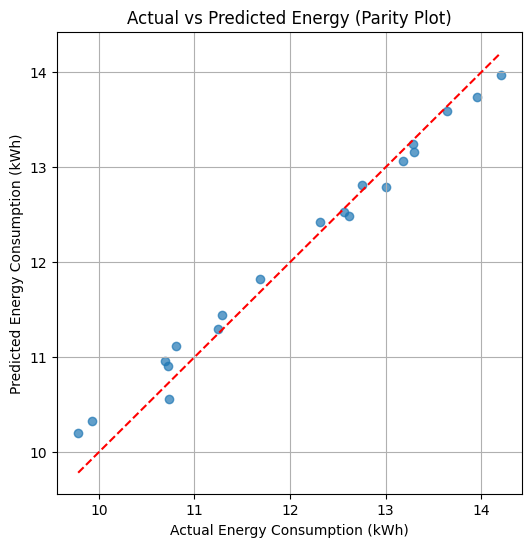

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                        │ (None, 1, 64)               │          28,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 1, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 124,133 (484.90 KB)

 Trainable params: 41,377 (161.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 82,756 (323.27 KB)

In [5]:

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error


# Load dataset
file_path = "C:/Users/Anarghya/OneDrive/Desktop/major project/energy_consumption_dataset in csv.csv" 
df = pd.read_csv(file_path)

# Encode categorical variable (Weather)
df["Weather"] = LabelEncoder().fit_transform(df["Weather"])

# Select features and target
X = df.drop(columns=["Total Energy Consumption (kWh)"])
y = df["Total Energy Consumption (kWh)"]

# Normalize data
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Reshape for LSTM (samples, time steps, features)
X_lstm = np.reshape(X_scaled, (X_scaled.shape[0], 1, X_scaled.shape[1]))

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_lstm, y_scaled, test_size=0.2, random_state=42, shuffle=True)

# Define LSTM model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(1, X_train.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

# Compile model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Train model with early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100, batch_size=8, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)

# Predictions
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_inv = scaler_y.inverse_transform(y_test)

# Display Prediction
print(y_pred)

# Evaluation Metrics
mse = mean_squared_error(y_test_inv, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_inv, y_pred)
mae = mean_absolute_error(y_test_inv, y_pred)


print(f"\nMSE: {mse:.4f}\nRMSE: {rmse:.4f}\nR²: {r2:.4f}\nMAE: {mae:.4f}")

mape = np.mean(np.abs((y_test_inv - y_pred) / y_test_inv)) * 100
print("MAPE: ", mape)

residuals = y_test_inv.flatten() - y_pred.flatten()
plt.figure(figsize=(8, 4))
plt.scatter(range(len(residuals)), residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals of Predictions")
plt.xlabel("Sample")
plt.ylabel("Residual (Actual - Predicted)")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_test_inv, y_pred, alpha=0.7)
plt.plot([min(y_test_inv), max(y_test_inv)], [min(y_test_inv), max(y_test_inv)], 'r--')
plt.xlabel("Actual Energy Consumption (kWh)")
plt.ylabel("Predicted Energy Consumption (kWh)")
plt.title("Actual vs Predicted Energy (Parity Plot)")
plt.grid(True)
plt.show()

model.summary()

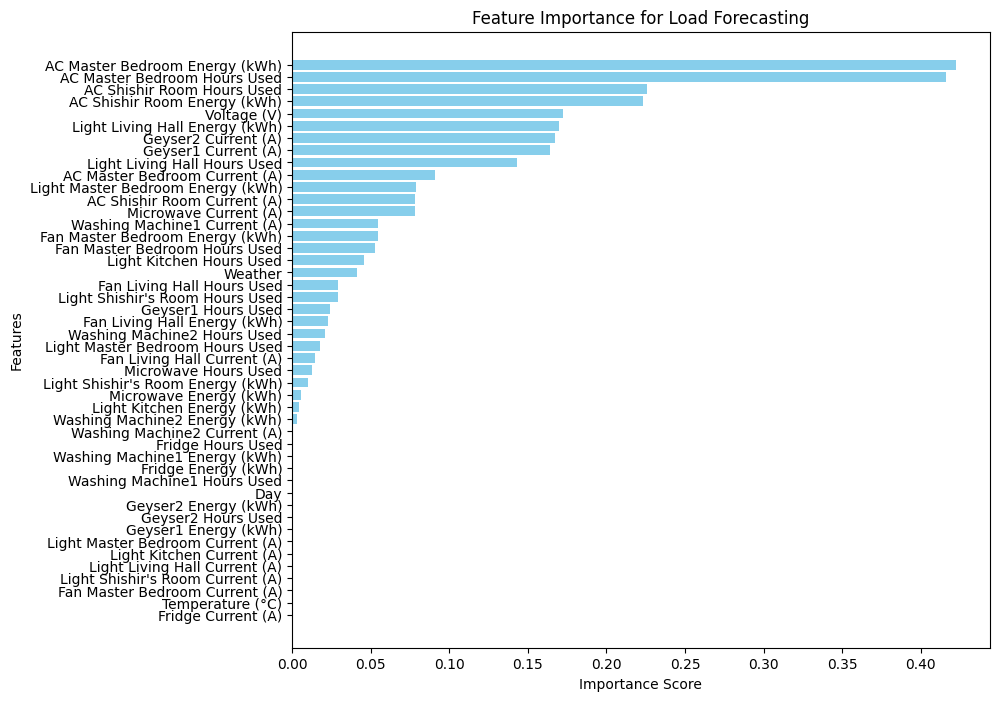

In [4]:
# Plot feature importance
plt.figure(figsize=(9, 8))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"], color='skyblue')
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance for Load Forecasting")
plt.gca().invert_yaxis()
plt.show()